Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example: (REMOVE THIS)

In [ ]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = './data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

### Initial Setup - Modules, Display options, Data Path

In [1]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.tree import DecisionTreeRegressor

# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Set plot style for consistent and visually appealing graphs
plt.style.use('seaborn-v0_8-whitegrid')

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

In [2]:
# Step 1 - Import and merge SCE data from all waves, keeping only relevant columns and parsing dates

# Variables with large share of NAs where dropped before implementing final solution

# Variables asked only at the first interview → need forward-filling
COLS_FIRST_WAVE = [
    'owner',
    'num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct',
    'num_lit_q5_correct', 'num_lit_q6_correct'
]

# Variables related to expectations → need outlier treatment
COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']

# Define titles for the expectation variable plots
titles = [
    'Expected Inflation (1-year ahead, %)',
    'Expected House Price Change (%)',
    'Probability Unemployment Goes Up (%)',
    'Probability Stocks Go Up (%)'
]

# Create a list of (column, title) pairs for plotting
exp_plot_vars = list(zip(COLS_EXPECTATIONS, titles))

# Variables related to individual characteristics → no cleaning needed
COLS_INDIVIDUAL = [
    'female', 'hispanic', 'black', 'educ',
    'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init'
]

# Variables to keep for analysis (expectations + first-wave + individual characteristics)
ANALYSIS_COLS = COLS_EXPECTATIONS + COLS_FIRST_WAVE + COLS_INDIVIDUAL

# Metadata columns to keep for merging and panel structure (Weight dropped - not needed for analysis, not compatible with all scikit-learn methods)
COLS_META = ['userid', 'wid', 'date', 'tenure']

# All variables to read from the CSV files (Defined before reading files to avoid reading unnecessary columns)
ALL_COLS  = COLS_META + ANALYSIS_COLS

# Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))

sce = pd.concat(
    [pd.read_csv(f, usecols=lambda c: c in ALL_COLS, parse_dates=['date']) for f in files],
    ignore_index=True
).sort_values(['userid', 'date']).reset_index(drop=True)

# Verify that all expected columns are present
assert set(ALL_COLS).issubset(sce.columns), (
    f"Missing columns: {set(ALL_COLS) - set(sce.columns)}"
)

# Initial data summary
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

In [3]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

In [4]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


In [5]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


In [7]:
# Step 5 - Trimming outliers
# Compute all percentiles upfront
percentiles = {col: (sce[col].quantile(0.01), sce[col].quantile(0.99)) for col in COLS_EXPECTATIONS}
obs_dropped_outliers = 0

for col in COLS_EXPECTATIONS:
    p1, p99 = percentiles[col]
    n_before = len(sce)
    sce = sce[(sce[col] > p1) & (sce[col] < p99)]
    print(f"  {col}: P1={p1:.2f}, P99={p99:.2f} → dropped {n_before - len(sce):,} obs")
    obs_dropped_outliers += n_before - len(sce)

# Reset index
sce = sce.reset_index(drop=True)

print('-' * 60)
print(f"Step 5 — Dropped a total of {obs_dropped_outliers:,} observations as outliers")

  infl_1y: P1=-30.00, P99=60.00 → dropped 3,400 obs
  house_price_change: P1=-20.00, P99=50.00 → dropped 3,790 obs
  prob_unrate_up: P1=0.00, P99=100.00 → dropped 4,034 obs
  prob_stocks_up: P1=0.00, P99=95.00 → dropped 2,394 obs
------------------------------------------------------------
Step 5 — Dropped a total of 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

In [8]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Labels for the optimism indicators
opt_titles = [
    'Unemployment Optimists (prob < 50%)',
    'Stock Market Optimists (prob > 50%)',
    'House Price Optimists (change > 0%)'
]

# Create a list of (column, title) pairs for plotting
opt_plot_vars = list(zip(OPTIMISM_COLS, opt_titles))

In [9]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), 'No Change'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,No Change,-121 days


The final sample of $145,517$ observations is close to the target of ~$150,000$

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the "data" folder. **Yahoo Finance** data was downloaded programmatically using yfinance, while **FRED** data was downloaded manually from fred.stlouisfed.org. All series are resampled to monthly frequency. To avoid look-ahead bias, each series is shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t−1$. For quarterly series (GDP, House Price Index), values are forward-filled within the quarter.

Additionally, we added two series not mentioned in the assignment - CBOE Volatility Index (VIX) and US 10-year treasury yield. 
- VIX captures uncertainty directly, which could be relevant for prob_stocks_up and general economic expectations.  
- The 10-year treasury yield as the long end of the yield curve embeds market participants' inflation and growth expectations, making it a good candidate for modelling infl_1y. 

Variables are included both in levels and as changes:

- Levels capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- 12-month changes capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).
- 1-month changes are computed for monthly series only and capture short-run surprises.
- VIX is kept only in levels since it is already a measure of reltive uncertainty. Percentage changes would be harder to interpret economically. 

For series expressed as index or price levels (CPI, House Price Index, Real GDP, USD Index, WTI Crude Oil, S&P 500), changes are expressed as percentage growth rates, since a one-unit absolute difference is not economically meaningful. For series already expressed in percentage terms (Federal Funds Rate, Unemployment Rate, 30-Year Mortgage Rate), changes are expressed as percentage-point differences, since a relative change (e.g. "the fed funds rate doubled") would be misleading when the level is near zero.
The final selection of which transformations to use as predictors is deferred to Parts 5 and 6, guided by the correlation analysis in Part 4.

In [10]:
# Read and combine Yahoo data (downloaded programmatically and stored in the data directory as CSV files)
wti   = pd.read_csv(f'{DATA_PATH}/wti_crude_oil.csv', parse_dates=['date'], index_col='date')
sp500 = pd.read_csv(f'{DATA_PATH}/sp500.csv', parse_dates=['date'], index_col='date')

# Create a dictionary to hold the raw Yahoo Finance series
yahoo_series = {"wti_crude_oil": wti, "sp500": sp500}

# Initialize an empty list to store the monthly resampled dataframes
yahoo_m = []

# Resample to month-end frequency, compute returns, and shift by one month to avoid look-ahead bias
for col, raw in yahoo_series.items():
    m = raw.resample("ME").last()
    m[f"{col}_chg"]     = m[col].pct_change()
    m[f"{col}_chg_12m"] = m[col].pct_change(12)
    yahoo_m.append(m.shift(1))

# Concatenate all monthly resampled dataframes into a single DataFrame
yahoo_all = pd.concat(yahoo_m, axis=1)

Yahoo Finance series are loaded and merged, with 1-month and 12-month change calculations performed, and observations shifted by a month.

Note that date range is not limited to SCE data at this point, and with the data starting in January 2010 all returns variables have some NA's. After merging with macro and SCE, there will be none. 

In [11]:
# Configuration: name -> (filename, is_quarterly, change_type)
# pct: price/index series — changes as % growth rates
# diff: series already in % terms — changes as percentage-point differences
# None: no change computed for VIX, where levels are more interpretable than changes
FRED_CONFIG = {
    "cpi":              ("CPIAUCSL.csv",     False, "pct"),
    "house_price_idx":  ("USSTHPI.csv",      True,  "pct"),
    "federal_funds":    ("FEDFUNDS.csv",     False, "diff"),
    "unemployment":     ("UNRATE.csv",       False, "diff"),
    "real_gdp":         ("GDPC1.csv",        True,  "pct"),
    "usd_index":        ("DTWEXBGS.csv",     False, "pct"),
    "mortgage_30y":     ("MORTGAGE30US.csv", False, "diff"),
    "10y_yield":        ("DGS10.csv",        False, "diff"),
    "vix":              ("VIXCLS.csv",       False, None),
}

# Initialize an empty dictionary to hold the monthly resampled macro/finance series
macro_m = {}

# Loop through the FRED_CONFIG to read, process, and compute changes for each macro/finance series
for name, (fname, is_quarterly, chg_fn) in FRED_CONFIG.items():
    s = pd.read_csv(
        f"{DATA_PATH}/{fname}",
        parse_dates=[0], index_col=0,
        header=0, names=["date", name],
    )
    # For quarterly series, shift the index to the end of the quarter to align with SCE survey timing
    if is_quarterly:
        s.index = s.index + pd.offsets.QuarterEnd(0)
    # Resample to month-end frequency, taking the last observation in each month (for quarterly series, this will forward-fill the value for the months within the quarter)
    s_m = s.resample("ME").last()

    if is_quarterly:
        s_m = s_m.ffill()

    # Compute changes based on the specified change type
    if chg_fn is not None:
        # Percentage change for price/index series
        if chg_fn == "pct":
            chg12 = s_m[name].pct_change(12, fill_method=None) * 100
            chg1  = s_m[name].pct_change(1,  fill_method=None) * 100
        # Percentage-point difference for series already in % terms
        elif chg_fn == "diff":
            chg12 = s_m[name].diff(12)
            chg1  = s_m[name].diff(1)
        # If no valid change type is specified, raise an error
        else:
            raise ValueError(f"Unknown change type {chg_fn!r} for series {name!r}")
        
        # Add the computed changes to the monthly dataframe with appropriate column names
        s_m[f"{name}_chg12m"] = chg12

        # 1-month change for non-quarterly series only
        if not is_quarterly:
            s_m[f"{name}_chg1m"] = chg1

    macro_m[name] = s_m

# Concatenate all monthly resampled macro/finance series into a single DataFrame
macro_all = (
    pd.concat([s.shift(1) for s in macro_m.values()], axis=1)
      .sort_index()
)

# Limit date range to match the SCE survey period
macro_all = macro_all.loc[
    (macro_all.index >= sce["date"].min()) &
    (macro_all.index <= sce["date"].max())
]

Macro data sets are loaded and merged, with 1-month and 12-month changes calculated for all variables (except VIX).

In [12]:
# Merge Yahoo Finance data into the monthly macro panel
macro_all = macro_all.join(yahoo_all, how="left")
macro_all = macro_all.sort_index()

# Prepare SCE data for merging: create a month-end date key (date_me) that maps each interview date to the corresponding month-end
sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

# Prepare macro_all for merging: reset date index into a column named 'date_me'
macro_for_merge = macro_all.rename_axis('date_me').reset_index()

# Left-join SCE with macro panel, then drop the temporary merge key
sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

# Store the list of macro/finance columns for later use (all columns that are not in the previously defined sets)
MACRO_COLS = [
    c for c in sce_data.columns
    if c not in set(
        COLS_META
        + COLS_EXPECTATIONS
        + COLS_FIRST_WAVE
        + COLS_INDIVIDUAL
        + OPTIMISM_COLS
    )
]

# Verify the merge worked correctly
print(f"SCE observations: {len(sce_data):}")
print(f"Macro/Finance panel observations: {len(macro_for_merge):,}")
print(f'Total NA values after final merge: {(sce_data.isna().sum()).sum():,}')
print("\nSample of macro columns for first few rows:")
display(sce_data[['date', 'cpi', 'unemployment', 'sp500', 'wti_crude_oil']].tail())

SCE observations: 145517
Macro/Finance panel observations: 139
Total NA values after final merge: 0

Sample of macro columns for first few rows:


,date,cpi,unemployment,sp500,wti_crude_oil
145512,2024-12-19,316.528,4.2,6032.379883,68.0
145513,2024-12-02,316.528,4.2,6032.379883,68.0
145514,2024-12-20,316.528,4.2,6032.379883,68.0
145515,2024-12-05,316.528,4.2,6032.379883,68.0
145516,2024-12-12,316.528,4.2,6032.379883,68.0


All macroeconomic and finance data merged with SCE, limited to SCE date range and shifted by a month to reflect real time information. 

## Part 3 - Exploratory Data Analysis (SCE)

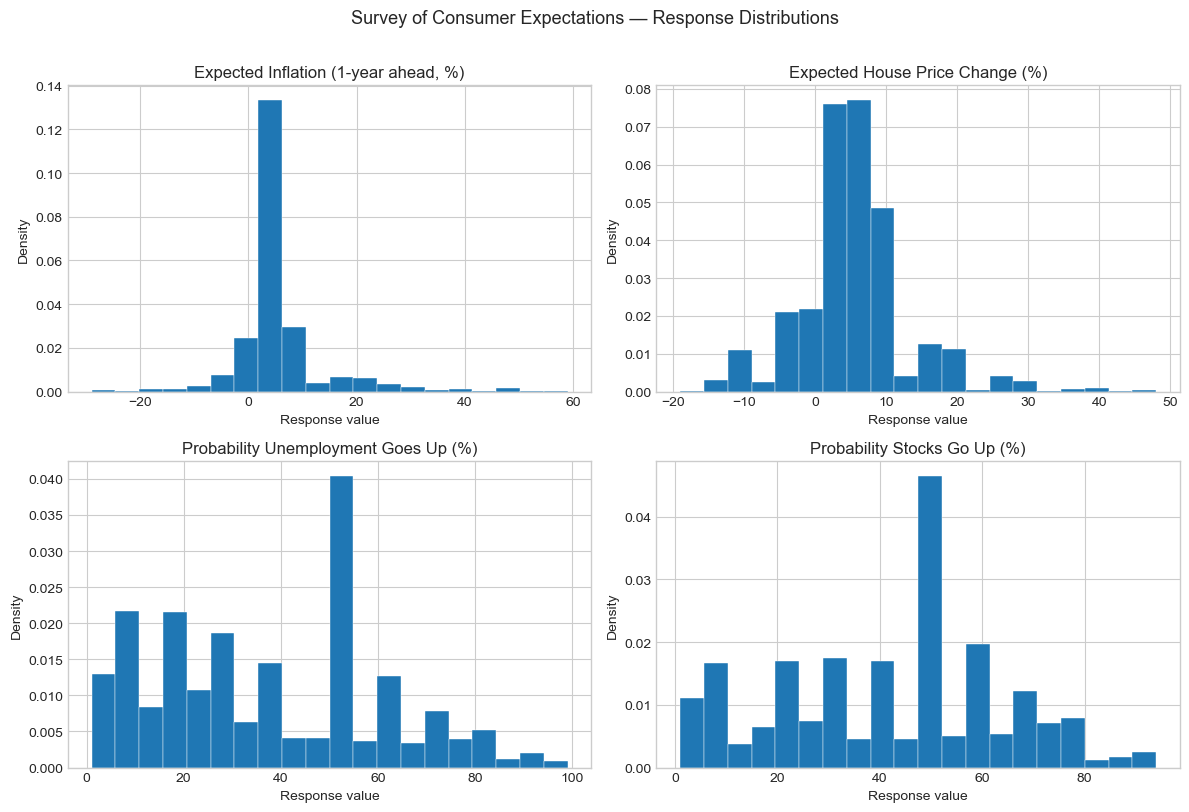

In [13]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop through the variables and create histograms
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.hist(sce_data[col].dropna(), bins=20, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Density')

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
_ = plt.tight_layout()

All four distributions show strong bunching at round numbers - respondents tend to report values in multiples of 5 or 10, which is a well-known feature of survey data. Expected inflation is right-skewed with a sharp peak near zero, reflecting that most respondents expect low but positive inflation. Expected house price change is similarly concentrated around small positive values. The probability variables (prob_unrate_up and prob_stocks_up) show pronounced spikes at 50, suggesting many respondents express maximal uncertainty by reporting exactly 50%. Note that these histograms are presented after trimming outliers P1 and P99. The distributions still show signs of some strong outliers, mainly in the first two subplots. 

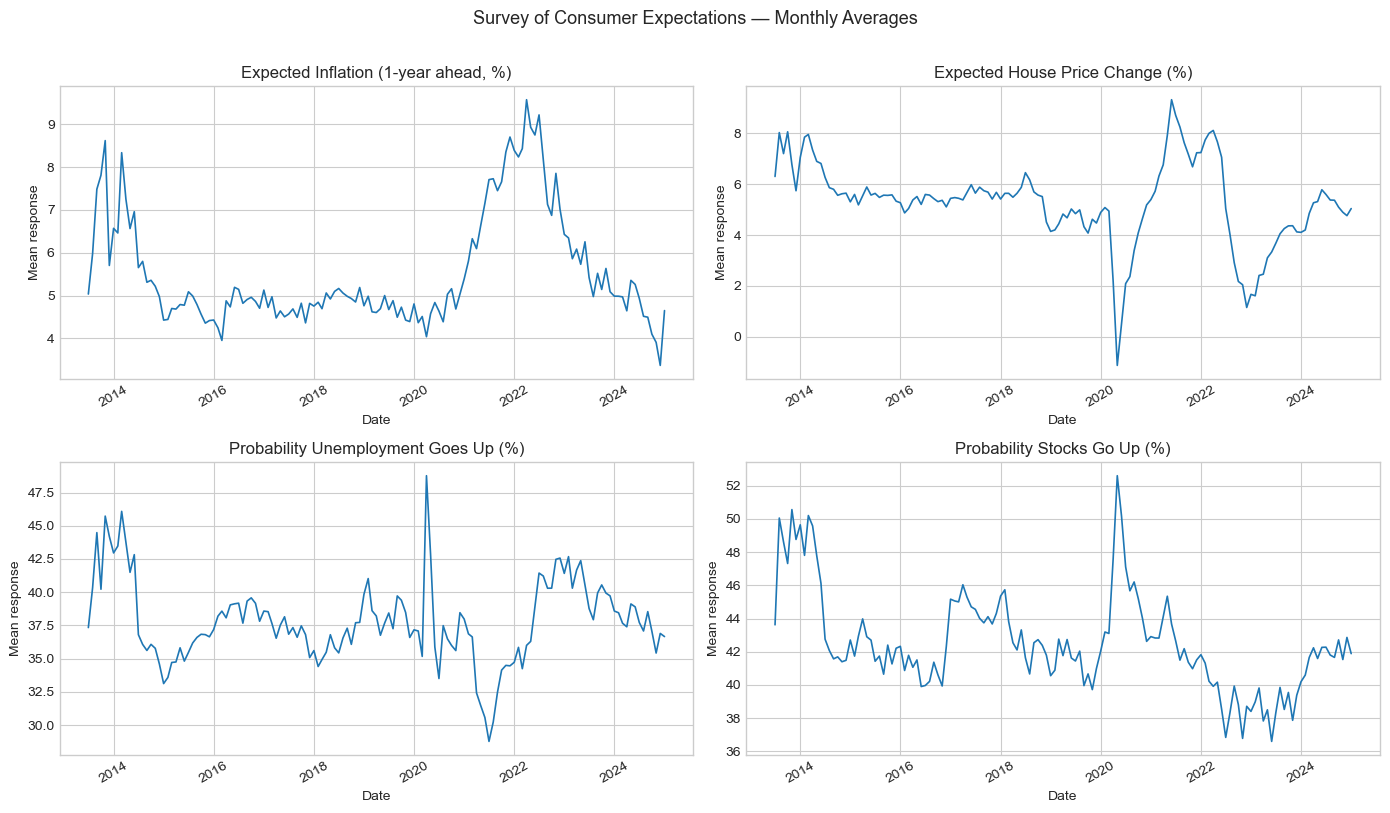

In [14]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
# Compute monthly means for the expectation variables using the month-end date key (date_me) to group by month
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[COLS_EXPECTATIONS]
    .mean()
)

# Create a 2x2 grid of subplots for the expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through the variables and create time series plots (Variables and titles defined in the previous step as plot_vars)
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
_ = plt.tight_layout()

Inflation expectations were elevated in 2013–2014, declined to a stable low around 4–5% through 2015–2019, then surged sharply from 2021 peaking above 9% in 2022 during the post-COVID inflation episode before declining again. House price expectations collapsed in early 2020 (COVID shock) but recovered rapidly. Unemployment pessimism spiked briefly in March–April 2020 before reverting. Stock market optimism has remained persistently below 50% throughout the sample, suggesting consumers are generally pessimistic about equity market gains.

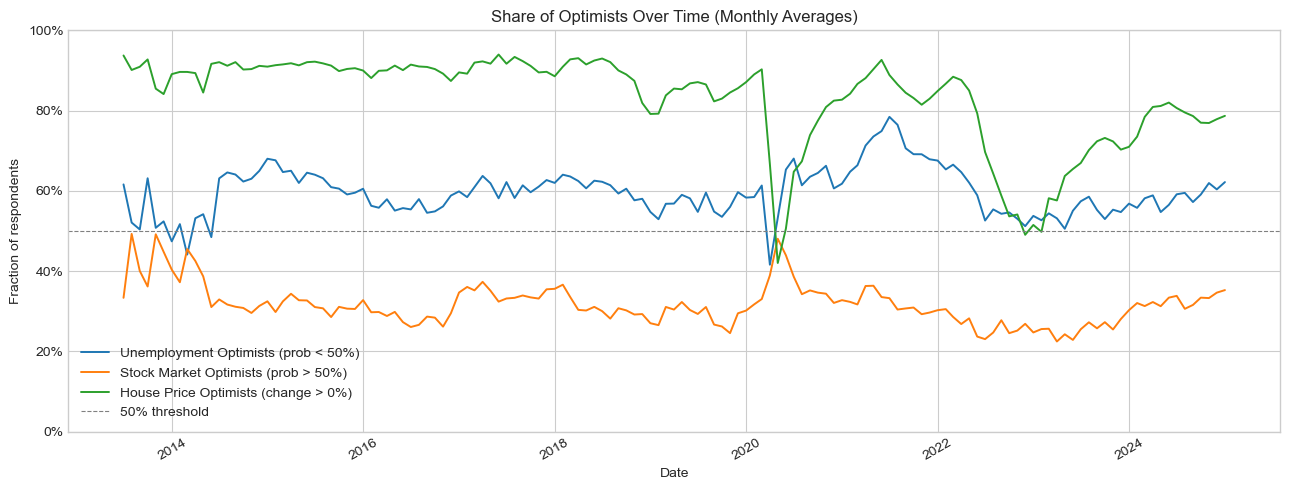

In [15]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Compute monthly means of the optimism indicators (performed on sce as macro/finance in sce_data is not needed here - computational efficiency)
optimism_means = (
    sce
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col, title in opt_plot_vars:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=title)

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

House price optimists consistently make up the large majority of respondents (~85–90% in normal times), reflecting a deeply held belief that house prices tend to rise. Stock market optimists are consistently the minority (~30–35%), suggesting persistent pessimism about equities among households. The COVID shock in early 2020 is visible as a sharp drop in House price and Unemployment optimists, and a spike in Stock market optimists, followed by a rapid recovery. House price optimists also dropped significantly around 2023.

## Part 4 - Exploratory Data Analysis (Macro/Finance)

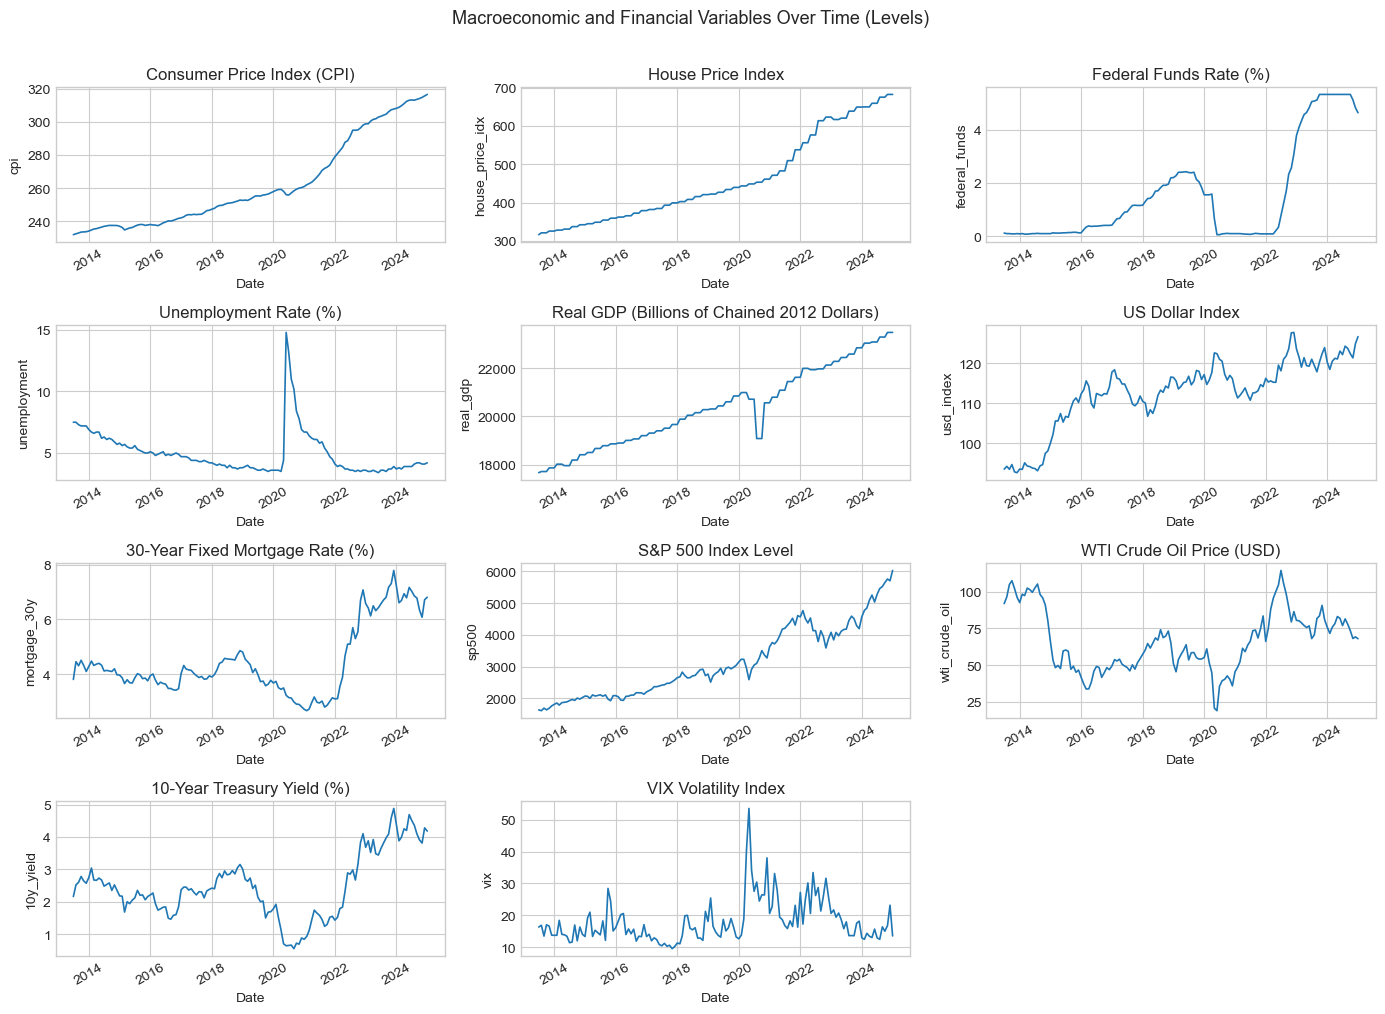

In [16]:
# Step 1 - Plot macro/finance variables in levels over time
# Variables to plot with their corresponding titles
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)'),
    ('10y_yield', '10-Year Treasury Yield (%)'),
    ('vix', 'VIX Volatility Index'),
]

# Initialize a 4x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
axes.flat[-1].set_visible(False)  # Hide the last empty subplot
fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)
_ = plt.tight_layout()

The levels plots reveal several key macroeconomic trends over the sample period. CPI and house prices grew steadily throughout, with house prices accelerating sharply post-2020. The Federal Funds Rate and mortgage rate dropped to near zero during COVID and rose sharply in 2022–2023 as the Fed tightened monetary policy. Unemployment spiked dramatically in early 2020 before recovering rapidly. The S&P 500 trended upward throughout with a sharp correction in early 2020. WTI crude oil was volatile, collapsing in 2020 before recovering. VIX spiked sharply in early 2020, reflecting peak market uncertainty during the pandemic.

# REMEMBER TO SET YLABEL BELOW

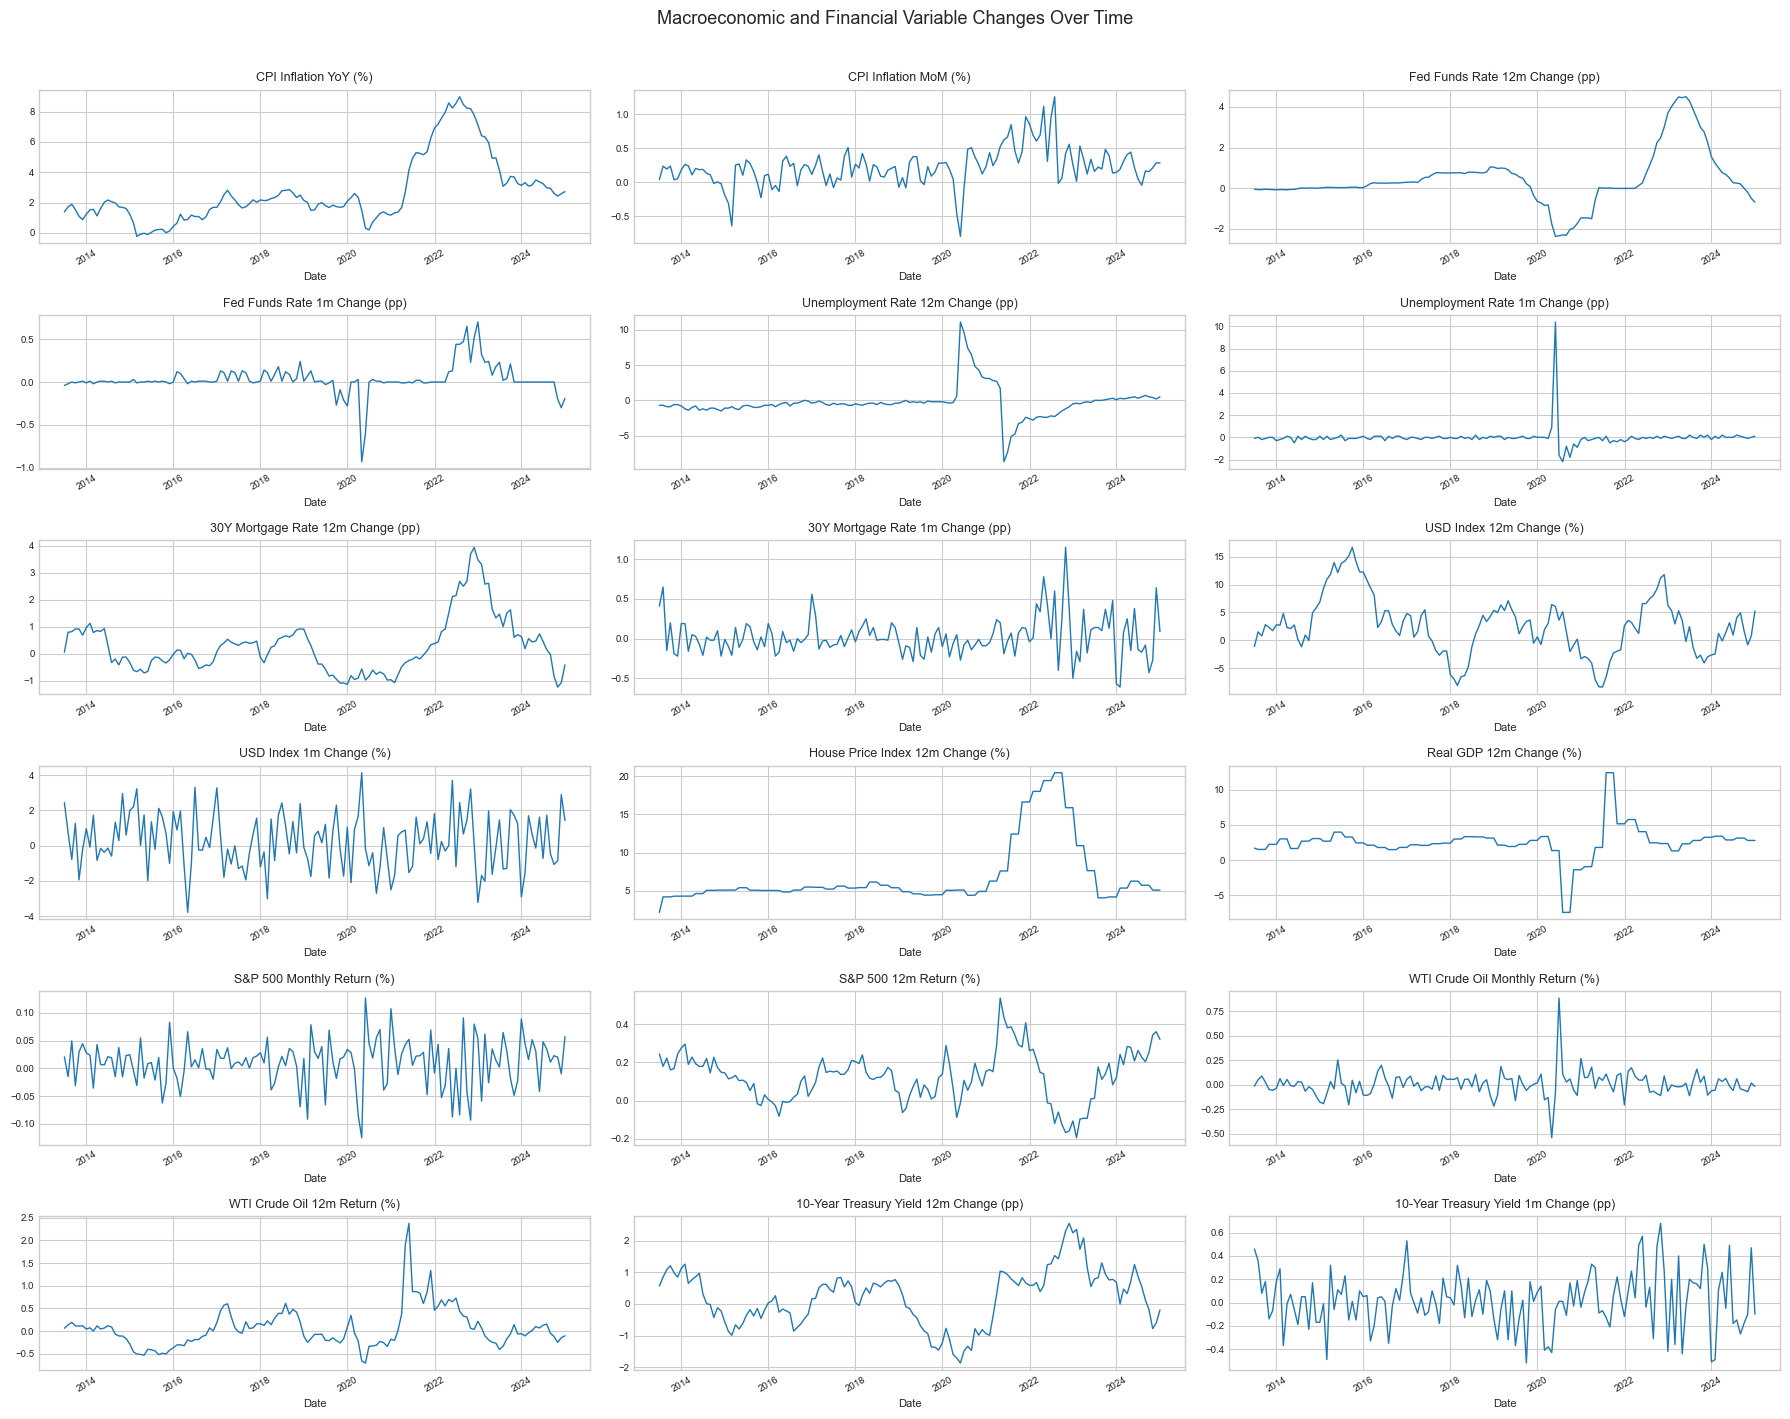

In [17]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time
# Variables to plot with their corresponding titles (Defined as 12-month and 1-month changes in the previous steps)
macro_vars_changes = [
    ('cpi_chg12m',             'CPI Inflation YoY (%)'),
    ('cpi_chg1m',              'CPI Inflation MoM (%)'),
    ('federal_funds_chg12m',   'Fed Funds Rate 12m Change (pp)'),
    ('federal_funds_chg1m',    'Fed Funds Rate 1m Change (pp)'),
    ('unemployment_chg12m',    'Unemployment Rate 12m Change (pp)'),
    ('unemployment_chg1m',     'Unemployment Rate 1m Change (pp)'),
    ('mortgage_30y_chg12m',    '30Y Mortgage Rate 12m Change (pp)'),
    ('mortgage_30y_chg1m',     '30Y Mortgage Rate 1m Change (pp)'),
    ('usd_index_chg12m',       'USD Index 12m Change (%)'),
    ('usd_index_chg1m',        'USD Index 1m Change (%)'),
    ('house_price_idx_chg12m', 'House Price Index 12m Change (%)'),
    ('real_gdp_chg12m',        'Real GDP 12m Change (%)'),
    ('sp500_chg',              'S&P 500 Monthly Return (%)'),
    ('sp500_chg_12m',          'S&P 500 12m Return (%)'),
    ('wti_crude_oil_chg',      'WTI Crude Oil Monthly Return (%)'),
    ('wti_crude_oil_chg_12m',  'WTI Crude Oil 12m Return (%)'),
    ('10y_yield_chg12m',   '10-Year Treasury Yield 12m Change (pp)'),
    ('10y_yield_chg1m',    '10-Year Treasury Yield 1m Change (pp)')
]

# Initialize a 6x3 grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(6, 3, figsize=(18, 14))

# Loop through the macro and finance variables in changes and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)
_ = plt.tight_layout()

The changes plots highlight episodes of macroeconomic stress more clearly than the levels. CPI inflation surged in 2021–2022 to multi-decade highs before declining. The Federal Funds Rate saw its largest 12-month increase in decades during 2022–2023. Unemployment changes were dominated by the COVID shock. S&P 500 and WTI returns show high volatility throughout, with large negative values in early 2020. The 10-year yield changes mirror the Federal Funds Rate, rising sharply in 2022.

In [18]:
# Step 3 – Correlation between macro/finance variables and expectations variables

# 1. Identify macro/finance columns

# 2. Compute wide correlation matrix: rows = macro vars, columns = expectations
corr_wide = (
    sce_data[MACRO_COLS + COLS_EXPECTATIONS]
    .corr()
    .loc[MACRO_COLS, COLS_EXPECTATIONS]   # macro rows, expectation columns
)

# 3. Sort rows by |correlation| with a reference target (first expectations variable)
REF_TARGET = COLS_EXPECTATIONS[0]   # e.g. 'infl_1y'
corr_sorted = (
    corr_wide
    .assign(_abs_ref=lambda df: df[REF_TARGET].abs())
    .sort_values("_abs_ref", ascending=False)
    .drop(columns="_abs_ref")
)

# 4. Style with color gradients to show correlation strength
#    (signed correlations, blue = positive, red = negative)
styled_corr = (
    corr_sorted
    .style
    .background_gradient(cmap="RdBu_r", vmin=-1, vmax=1)
    .set_caption(
        f"Correlations between macro/finance variables and expectations "
        f"(rows sorted by |corr with {REF_TARGET}|)"
    )
)

styled_corr

,infl_1y,house_price_change,prob_unrate_up,prob_stocks_up
house_price_idx_chg12m,0.125697,0.013385,0.005844,-0.045744
cpi_chg12m,0.118191,-0.001555,0.020979,-0.054776
cpi_chg1m,0.091943,0.069073,-0.013459,-0.033136
wti_crude_oil_chg_12m,0.088985,0.108881,-0.042259,-0.001829
wti_crude_oil,0.087772,0.037303,0.013414,-0.047962
10y_yield_chg12m,0.077074,0.012525,0.023853,-0.044863
mortgage_30y_chg12m,0.072578,-0.055982,0.056567,-0.054080
unemployment_chg12m,-0.061506,-0.102888,0.019585,0.038958
sp500,0.058356,-0.004097,-0.001116,-0.035236
house_price_idx,0.052536,-0.050098,0.028342,-0.049035


In [19]:
# Step 3 - Correlation between macro/finance variables and expectations variables
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    # Create a more readable table that combines variable names and correlation values
    print(f"\nCorrelations with {target}:")
    display(corr.style.background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15).format("{:.2f}"))



Correlations with infl_1y:


,correlation
house_price_idx_chg12m,0.13
cpi_chg12m,0.12
cpi_chg1m,0.09
wti_crude_oil_chg_12m,0.09
wti_crude_oil,0.09
10y_yield_chg12m,0.08
mortgage_30y_chg12m,0.07
unemployment_chg12m,-0.06
sp500,0.06
house_price_idx,0.05



Correlations with house_price_change:


,correlation
sp500_chg_12m,0.13
wti_crude_oil_chg_12m,0.11
unemployment_chg12m,-0.10
usd_index,-0.09
federal_funds,-0.08
mortgage_30y,-0.08
real_gdp_chg12m,0.07
vix,-0.07
cpi_chg1m,0.07
usd_index_chg12m,-0.06



Correlations with prob_unrate_up:


,correlation
sp500_chg_12m,-0.08
mortgage_30y_chg12m,0.06
mortgage_30y,0.06
federal_funds_chg12m,0.05
federal_funds,0.05
10y_yield,0.04
wti_crude_oil_chg_12m,-0.04
usd_index,0.04
unemployment,-0.04
usd_index_chg12m,0.03



Correlations with prob_stocks_up:


,correlation
federal_funds_chg12m,-0.07
unemployment,0.06
federal_funds_chg1m,-0.06
cpi_chg12m,-0.05
mortgage_30y_chg12m,-0.05
mortgage_30y,-0.05
cpi,-0.05
10y_yield,-0.05
house_price_idx,-0.05
wti_crude_oil,-0.05


Overall correlations between macro/finance variables and expectations are modest, with no variable exceeding 0.13 in absolute value. This suggests that macro variables alone have limited predictive power for individual-level expectations, which is consistent with the literature on heterogeneous beliefs. The strongest predictors of inflation expectations are house price momentum (house_price_idx_chg12m) and CPI changes, which is intuitive. For house price expectations, S&P 500 12-month returns and WTI crude oil returns are most correlated, suggesting that financial market sentiment spills over into housing expectations. Unemployment and stock market expectations show weaker macro correlations overall. VIX shows modest negative correlations with house_price_chg and prob_stocks_up, consistent with the view that higher uncertainty suppresses optimism about asset prices. Note that correaltions are computed on the full data set - not split in train and test.

## Part 5 - Predicting Continous Expectation Variables

In [20]:
# Choose Macro/Finance variables as predictors 
MACRO_PREDS = ['house_price_idx_chg12m', 'cpi_chg12m', 'wti_crude_oil_chg_12m', 'unemployment_chg12m', '10y_yield_chg12m']

# Choose SCE predictors for step 2

# one-hot encode the 'educ' variable to convert it into binary indicator variables for each education category
# List of unique categories
educ_uniq = list(np.sort(sce_data['educ'].unique()))

# Create dummy variable encoder
enc = OneHotEncoder(categories=[educ_uniq], sparse_output=False)

# Create column names for the dummies
educ_dummy_cols = [f"educ_{cat}" for cat in educ_uniq]

educ_dummies = enc.fit_transform(sce_data[['educ']])

# Make a DataFrame of the dummies
educ_df = pd.DataFrame(educ_dummies, columns=educ_dummy_cols, index=sce_data.index)

# Add to sce_data
sce_data = pd.concat([sce_data, educ_df], axis=1)

# Now define SCE_PREDS using the new dummy columns
SCE_PREDS = ['age_init', 'female', 'hh_inc_bin_rank', 'working', 'owner'] + educ_dummy_cols
ALL_PREDS = MACRO_PREDS + SCE_PREDS

Skriv tekst her (Motiver valg av variabler)

In [21]:
ridge_alphas = np.logspace(np.log10(1e-5), np.log10(10), 100)
lasso_alphas = np.logspace(np.log10(1e-4), np.log10(1), 50)

In [22]:
ridge = RidgeCV(
    alphas=ridge_alphas,
    cv=5,              
    # some versions ignore or don’t expose cv_values_
)

lasso = LassoCV(
    alphas=lasso_alphas,
    cv=5,
    random_state=0,
)

MODELS = {
    "OLS":   make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), ridge),
    "Lasso": make_pipeline(StandardScaler(), lasso),
}

In [26]:
FEATURE_SETS = {
    "Macro only":  MACRO_PREDS,
    "Macro + SCE": ALL_PREDS,
}

TARGETS = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

dates_train_mask = sce_data["date"].dt.year < 2024
dates_test_mask  = sce_data["date"].dt.year == 2024

train = sce_data[dates_train_mask].copy()
test  = sce_data[dates_test_mask].copy()

X_train_full = train[ALL_PREDS]
y_train_full = train[TARGETS]
X_test_full  = test[ALL_PREDS]
y_test_full  = test[TARGETS]

dates_train = train["date"]
dates_test  = test["date"]

## Part 6 - Predicting Binary Optimism Variables (Classification)

## Part 7 - Conclusion

# TESTING FOR PART 5

In [28]:
# Choose Macro/Finance variables as predictors 
MACRO_PREDS = ['house_price_idx_chg12m', 'cpi_chg12m', 'wti_crude_oil_chg_12m', 'unemployment_chg12m', '10y_yield_chg12m']

# Choose SCE predictors for step 2

# one-hot encode the 'educ' variable to convert it into binary indicator variables for each education category
# List of unique categories
educ_uniq = list(np.sort(sce_data['educ'].unique()))

# Create dummy variable encoder
enc = OneHotEncoder(categories=[educ_uniq], sparse_output=False)

# Create column names for the dummies
educ_dummy_cols = [f"educ_{cat}" for cat in educ_uniq]

educ_dummies = enc.fit_transform(sce_data[['educ']])

# Make a DataFrame of the dummies
educ_df = pd.DataFrame(educ_dummies, columns=educ_dummy_cols, index=sce_data.index)

# Add to sce_data
sce_data = pd.concat([sce_data, educ_df], axis=1)

# Now define SCE_PREDS using the new dummy columns
SCE_PREDS = ['age_init', 'female', 'hh_inc_bin_rank', 'working', 'owner'] + educ_dummy_cols
ALL_PREDS = MACRO_PREDS + SCE_PREDS

In [29]:
ridge_alphas = np.logspace(-2, 6, 50)
lasso_alphas = np.logspace(-4, 1, 50)
l1_ratios   = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]   # ElasticNet mixing grid
tree_depths = [2, 3, 5, 7, 10, 15, 20]                   # Tree depth grid

FEATURE_SETS = {
    "Macro only":  MACRO_PREDS,
    "Macro + SCE": ALL_PREDS,
}

# Targets and their labels for plotting
TARGETS = COLS_EXPECTATIONS
TARGET_LABELS = {
    "infl_1y": "Inflation Expectation (1 year)",
    "house_price_change": "Expected House Price Change",
    "prob_unrate_up": "Probability Unemployment Rate Up",
    "prob_stocks_up": "Probability Stock Market Up",
}

# Reset index so positional alignment works throughout
train = sce_data[sce_data["date"].dt.year < 2024].copy().reset_index(drop=True)
test  = sce_data[sce_data["date"].dt.year == 2024].copy().reset_index(drop=True)

X_train_full = train[ALL_PREDS]
y_train_full = train[TARGETS]
X_test_full  = test[ALL_PREDS]
y_test_full  = test[TARGETS]

dates_train = train["date"]
dates_test  = test["date"]

# TEST DATA - JOBBER HERFRA MED ENDELIG LØSNING

In [30]:
# Create a subset of data for testing functions
test_data = sce_data.sample(n=10_000, random_state=0)

ridge_alphas = np.logspace(-2, 6, 50)
lasso_alphas = np.logspace(-4, 1, 50)
l1_ratios   = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]   # ElasticNet mixing grid
tree_depths = [2, 3, 5, 7, 10, 15, 20]                   # Tree depth grid

FEATURE_SETS = {
    "Macro only":  MACRO_PREDS,
    "Macro + SCE": ALL_PREDS,
}

# Targets and their labels for plotting
TARGETS = COLS_EXPECTATIONS
TARGET_LABELS = {
    "infl_1y": "Inflation Expectation (1 year)",
    "house_price_change": "Expected House Price Change",
    "prob_unrate_up": "Probability Unemployment Rate Up",
    "prob_stocks_up": "Probability Stock Market Up",
}

# Reset index so positional alignment works throughout
train = test_data[test_data["date"].dt.year < 2024].copy().reset_index(drop=True)
test  = test_data[test_data["date"].dt.year == 2024].copy().reset_index(drop=True)

X_train_full = train[ALL_PREDS]
y_train_full = train[TARGETS]
X_test_full  = test[ALL_PREDS]
y_test_full  = test[TARGETS]

dates_train = train["date"]
dates_test  = test["date"]

In [31]:
def _monthly_mean(dates, values):
    """Average values by calendar month. Returns a Series indexed by month timestamp."""
    return pd.Series(
        np.asarray(values, dtype=float),
        index=pd.to_datetime(np.asarray(dates)).to_period("M").to_timestamp(),
    ).groupby(level=0).mean()

In [32]:
def fit_ridge_multioutput(X_train, y_train, alphas, cv=5):
    """
    Fit Ridge across all targets simultaneously using GridSearchCV.
    Uses k-fold CV (default 5) — avoids the LOO boundary issue with
    high-noise targets where LOO often selects the largest alpha.

    Returns (best_pipeline, best_alpha, sorted_alphas, mse_per_alpha).
    MSE is averaged across all targets by sklearn's uniform_average default.
    """
    gs = GridSearchCV(
        make_pipeline(StandardScaler(), Ridge()),
        param_grid={"ridge__alpha": alphas},
        cv=cv,
        scoring="r2",      # ← normalises by each target's variance → equal weight
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)

    best_alpha = gs.best_params_["ridge__alpha"]

    # Sort by alpha for a clean validation curve plot
    params    = np.array([p["ridge__alpha"] for p in gs.cv_results_["params"]])
    order     = np.argsort(params)
    mse_curve = gs.cv_results_["mean_test_score"][order]
    alphas_ord = params[order]

    return gs.best_estimator_, best_alpha, alphas_ord, mse_curve

In [33]:
def plot_ridge_validation_curve(alphas, mse_curve, best_alpha, feature_set_name):
    """
    Plot CV MSE vs alpha for Ridge.
    MSE is averaged across all four targets (multi-output with uniform_average).
    """
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogx(alphas, mse_curve)
    ax.axvline(best_alpha, color="red", linestyle="--", label=f"Best α = {best_alpha:.3g}")
    ax.set_xlabel(r"$\alpha$ (log scale)")
    ax.set_ylabel("CV R² (avg. across targets)")
    ax.set_title(f"Ridge — Validation curve ({feature_set_name})")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [34]:
def fit_lasso_per_target(X_train, y_train_series, alphas, cv=5):
    """
    Fit LassoCV for a single target.
    LassoCV stores alphas_ in descending order (warm-start direction),
    so we sort before returning for consistent plotting.

    Returns (fitted_pipeline, best_alpha, sorted_alphas, mse_per_alpha).
    """
    pipe = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=alphas, cv=cv, random_state=0, selection="random", n_jobs=-1),
    )
    pipe.fit(X_train, y_train_series)

    est       = pipe.named_steps["lassocv"]
    order     = np.argsort(est.alphas_)          # ascending alpha order
    alphas_ord = est.alphas_[order]
    mse_curve  = est.mse_path_[order].mean(axis=1)

    return pipe, est.alpha_, alphas_ord, mse_curve

In [35]:
def plot_lasso_validation_curves(lasso_results, feature_set_name):
    """
    2×2 subplot grid — one Lasso validation curve per target.
    lasso_results: {target: (best_alpha, sorted_alphas, mse_curve)}
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, target in zip(axes.flatten(), TARGETS):
        best_alpha, alphas, mse = lasso_results[target]
        ax.semilogx(alphas, mse, marker="o", markersize=2)
        ax.axvline(best_alpha, color="red", linestyle="--",
                   label=f"Best α = {best_alpha:.3g}", lw=1)
        ax.set_xlabel(r"$\alpha$ (log scale)")
        ax.set_ylabel("CV MSE")
        ax.set_title(TARGET_LABELS[target])
        ax.legend(fontsize=8)
    fig.suptitle(f"Lasso — Validation curves ({feature_set_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [36]:
def fit_elasticnet_per_target(X_train, y_train_series, l1_ratios, alphas, cv=5):
    pipe = make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            l1_ratio=l1_ratios,
            alphas=alphas,
            cv=cv,
            random_state=0,
            selection="random",
            n_jobs=-1,
        ),
    )
    pipe.fit(X_train, y_train_series)

    est        = pipe.named_steps["elasticnetcv"]
    best_alpha = est.alpha_
    best_l1    = est.l1_ratio_

    # est.alphas_ is always 1D — the same grid regardless of l1_ratio
    # Only mse_path_ is 3D (n_l1_ratios, n_alphas, n_folds) with multiple l1_ratios
    if est.mse_path_.ndim == 3:
        idx    = np.argmin(np.abs(np.asarray(l1_ratios) - best_l1))
        mse_2d = est.mse_path_[idx]   # (n_alphas, n_folds) for the best l1_ratio
    else:
        mse_2d = est.mse_path_         # (n_alphas, n_folds) — single l1_ratio case

    order      = np.argsort(est.alphas_)
    alphas_ord = est.alphas_[order]
    mse_curve  = mse_2d[order].mean(axis=1)

    return pipe, best_alpha, best_l1, alphas_ord, mse_curve

In [37]:
def plot_elasticnet_validation_curves(en_results, feature_set_name):
    """
    2×2 subplot grid — ElasticNet CV MSE vs alpha at the best l1_ratio, per target.
    en_results: {target: (best_alpha, best_l1_ratio, sorted_alphas, mse_curve)}
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, target in zip(axes.flatten(), TARGETS):
        best_alpha, best_l1, alphas, mse = en_results[target]
        ax.semilogx(alphas, mse, marker="o", markersize=2)
        ax.axvline(best_alpha, color="red", linestyle="--", lw=1,
                   label=f"Best α = {best_alpha:.3g}\nl1_ratio = {best_l1:.2f}")
        ax.set_xlabel(r"$\alpha$ (log scale)")
        ax.set_ylabel("CV MSE")
        ax.set_title(TARGET_LABELS[target])
        ax.legend(fontsize=8)
    fig.suptitle(f"ElasticNet — Validation curves ({feature_set_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [38]:
def fit_tree_per_target(X_train, y_train_series, depths, cv=5):
    """
    Fit DecisionTreeRegressor with GridSearchCV over max_depth.
    No feature scaling needed for trees.

    Returns (best_estimator, best_depth, sorted_depths, mse_per_depth).
    """
    gs = GridSearchCV(
        DecisionTreeRegressor(random_state=0),
        param_grid={"max_depth": depths},
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train_series)

    best_depth = gs.best_params_["max_depth"]

    params     = np.array([p["max_depth"] for p in gs.cv_results_["params"]])
    order      = np.argsort(params)
    depths_ord = params[order]
    mse_curve  = -gs.cv_results_["mean_test_score"][order]

    return gs.best_estimator_, best_depth, depths_ord, mse_curve

In [39]:
def plot_tree_validation_curves(tree_results, feature_set_name):
    """
    2×2 subplot grid — Decision Tree CV MSE vs max_depth, per target.
    tree_results: {target: (best_depth, sorted_depths, mse_curve)}
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, target in zip(axes.flatten(), TARGETS):
        best_depth, depths, mse = tree_results[target]
        ax.plot(depths, mse, marker="o", markersize=5)
        ax.axvline(best_depth, color="red", linestyle="--", lw=1,
                   label=f"Best depth = {best_depth}")
        ax.set_xlabel("max_depth")
        ax.set_ylabel("CV MSE")
        ax.set_title(TARGET_LABELS[target])
        ax.legend(fontsize=8)
    fig.suptitle(f"Decision Tree — Validation curves ({feature_set_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [40]:
def plot_ts_grid(dates_train, dates_test,
                 y_train_df, y_test_df,
                 preds_train, preds_test,
                 feature_set_name, split_date="2024-01-01"):
    COLORS = {
        "OLS":        "tab:purple",
        "Ridge":      "darkorange",
        "Lasso":      "tab:green",
        "ElasticNet": "tab:blue",
        "Tree":       "saddlebrown",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

    for ax, target in zip(axes.flatten(), TARGETS):
        actual = pd.concat([
            _monthly_mean(dates_train, y_train_df[target]),
            _monthly_mean(dates_test,  y_test_df[target]),
        ]).sort_index()
        ax.plot(actual.index, actual.values, color="black", lw=1, label="Actual")

        for model_name, color in COLORS.items():
            pred = pd.concat([
                _monthly_mean(dates_train, preds_train[target][model_name]),
                _monthly_mean(dates_test,  preds_test[target][model_name]),
            ]).sort_index()
            ax.plot(pred.index, pred.values, color=color,
                    linestyle="--", lw=1, label=model_name)

        ax.axvline(pd.Timestamp(split_date), color="red", linestyle=":",
                   lw=1.5, label="Train/Test split")
        ax.set_title(TARGET_LABELS[target])
        ax.set_ylabel(TARGET_LABELS[target])
        ax.legend(fontsize=7, ncol=3)

    fig.suptitle(f"Actual vs Predicted — {feature_set_name}", fontsize=13)
    plt.tight_layout()
    plt.show()


Feature set: Macro only
Fitting Ridge (multi-output, 5-fold CV)…
  Best α = 120.7


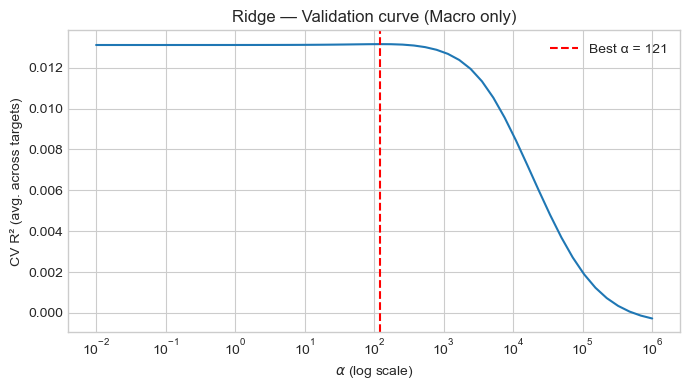

Fitting Lasso for infl_1y…
  Best α = 0.03556
Fitting ElasticNet for infl_1y…
  Best α = 0.1151  |  l1_ratio = 0.25
Fitting Decision Tree for infl_1y…
  Best max_depth = 2
Fitting Lasso for house_price_change…
  Best α = 0.0001
Fitting ElasticNet for house_price_change…
  Best α = 0.002683  |  l1_ratio = 0.10
Fitting Decision Tree for house_price_change…
  Best max_depth = 5
Fitting Lasso for prob_unrate_up…
  Best α = 0.1151
Fitting ElasticNet for prob_unrate_up…
  Best α = 0.1151  |  l1_ratio = 1.00
Fitting Decision Tree for prob_unrate_up…
  Best max_depth = 2
Fitting Lasso for prob_stocks_up…
  Best α = 0.03556
Fitting ElasticNet for prob_stocks_up…
  Best α = 0.03556  |  l1_ratio = 1.00
Fitting Decision Tree for prob_stocks_up…
  Best max_depth = 5


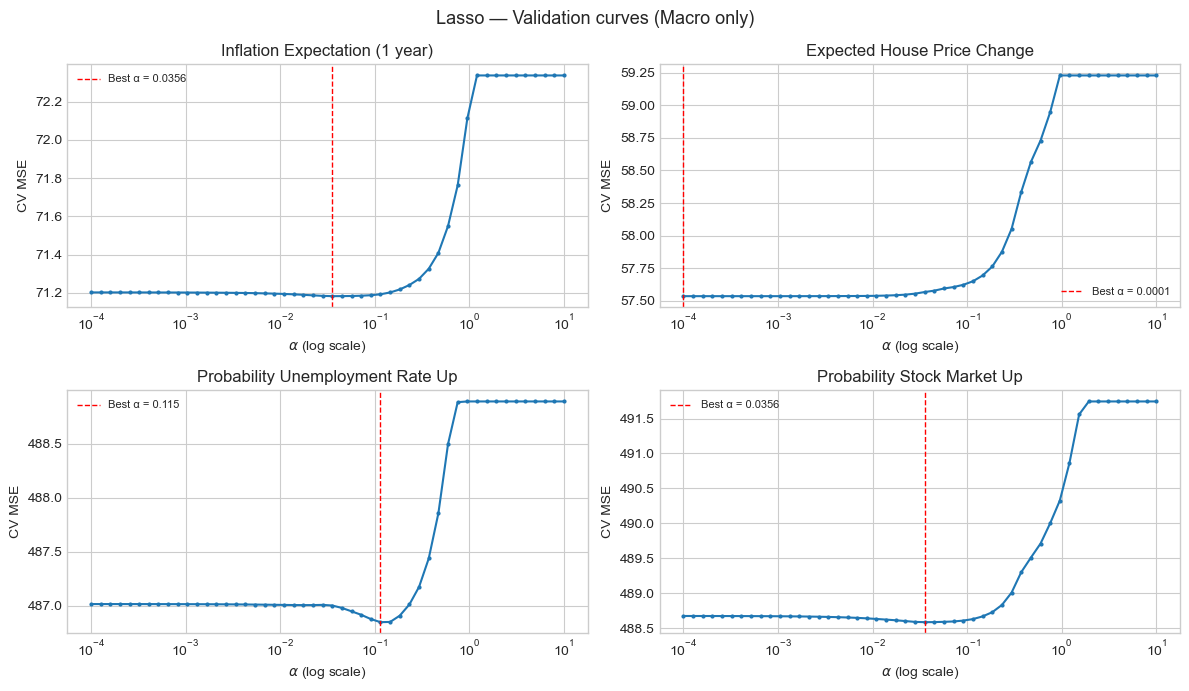

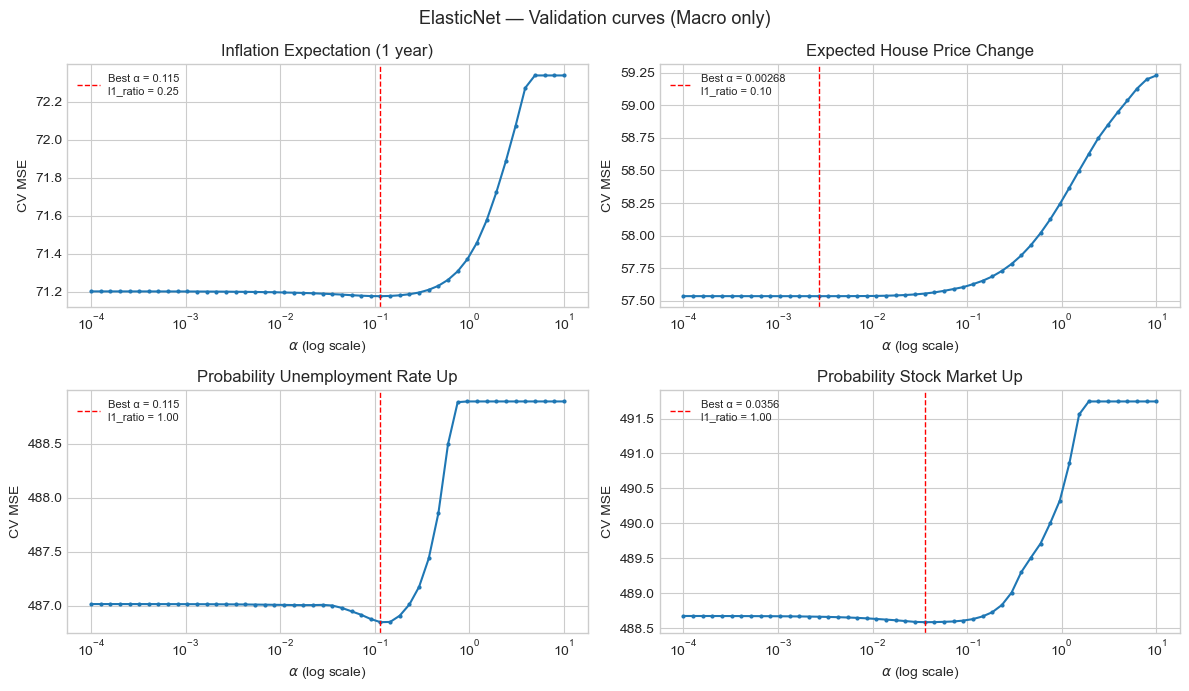

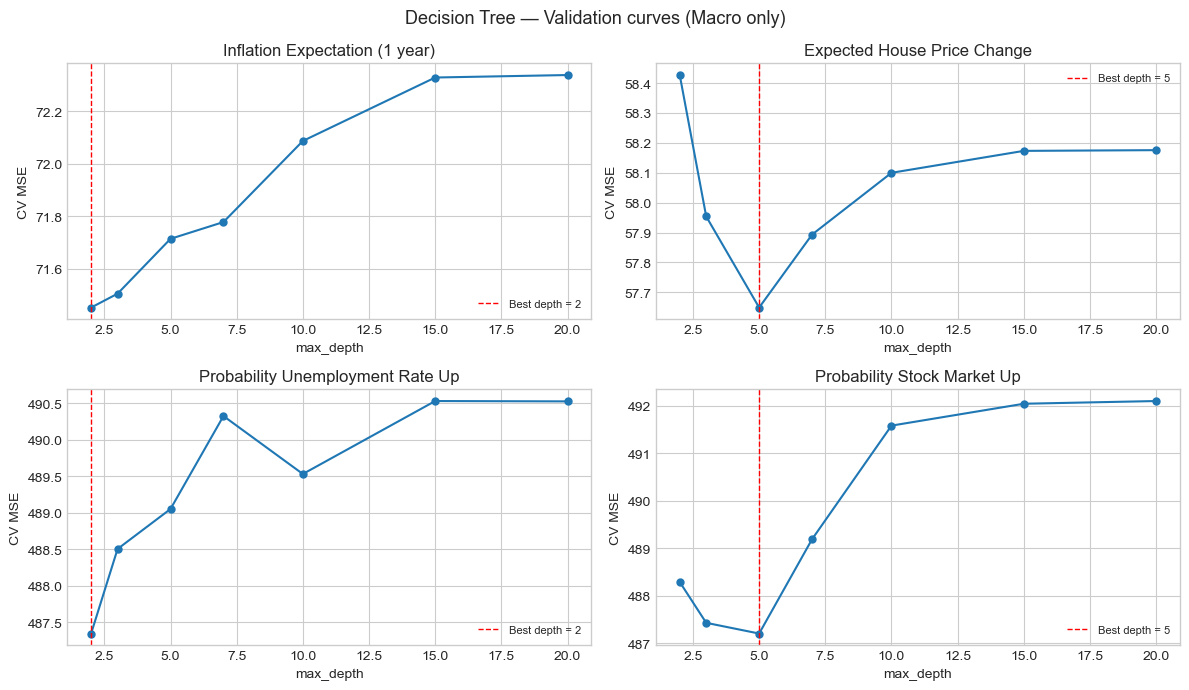

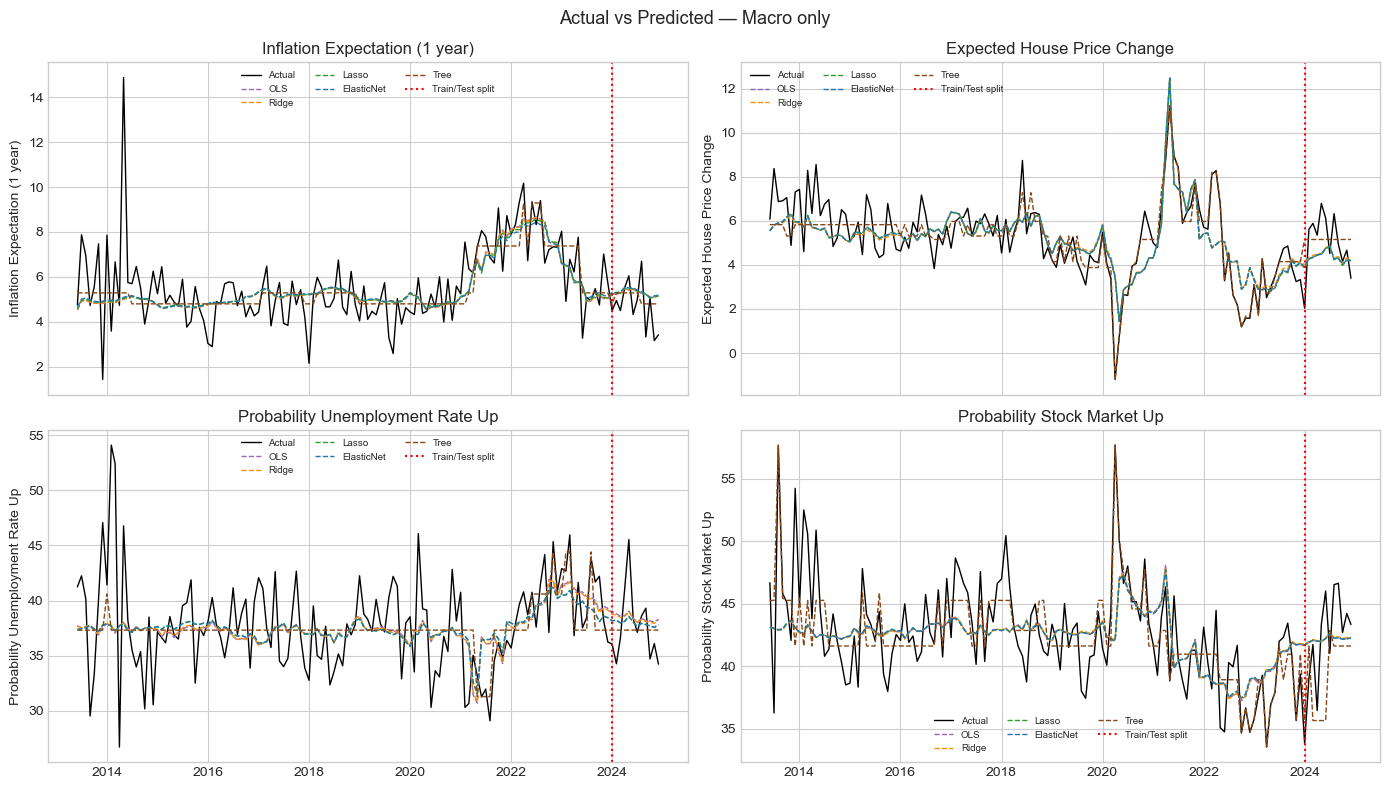


Feature set: Macro + SCE
Fitting Ridge (multi-output, 5-fold CV)…
  Best α = 120.7


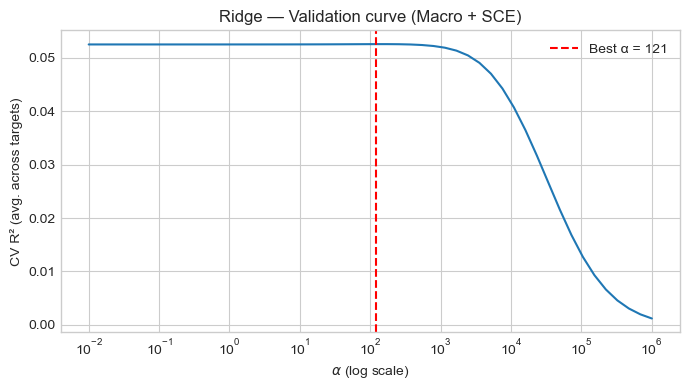

Fitting Lasso for infl_1y…
  Best α = 0.01758
Fitting ElasticNet for infl_1y…
  Best α = 0.0569  |  l1_ratio = 0.10
Fitting Decision Tree for infl_1y…
  Best max_depth = 5
Fitting Lasso for house_price_change…
  Best α = 0.005429
Fitting ElasticNet for house_price_change…
  Best α = 0.005429  |  l1_ratio = 1.00
Fitting Decision Tree for house_price_change…
  Best max_depth = 5
Fitting Lasso for prob_unrate_up…
  Best α = 0.1151
Fitting ElasticNet for prob_unrate_up…
  Best α = 0.1151  |  l1_ratio = 0.95
Fitting Decision Tree for prob_unrate_up…
  Best max_depth = 2
Fitting Lasso for prob_stocks_up…
  Best α = 0.01758
Fitting ElasticNet for prob_stocks_up…
  Best α = 0.04498  |  l1_ratio = 0.10
Fitting Decision Tree for prob_stocks_up…
  Best max_depth = 3


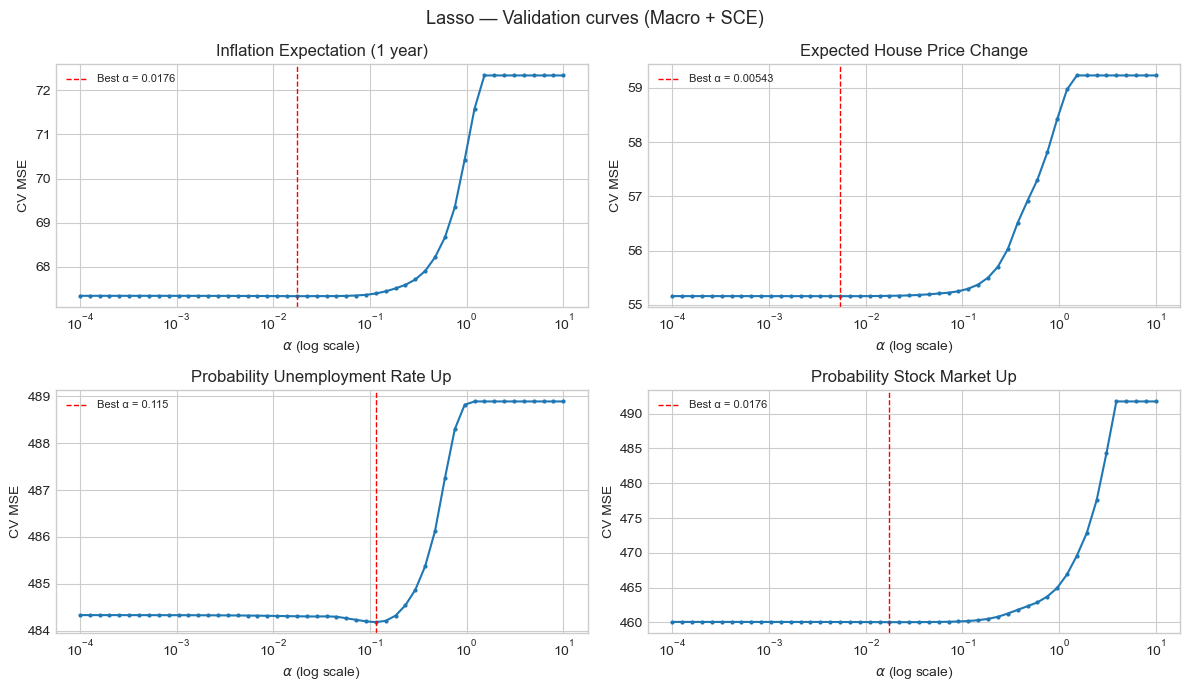

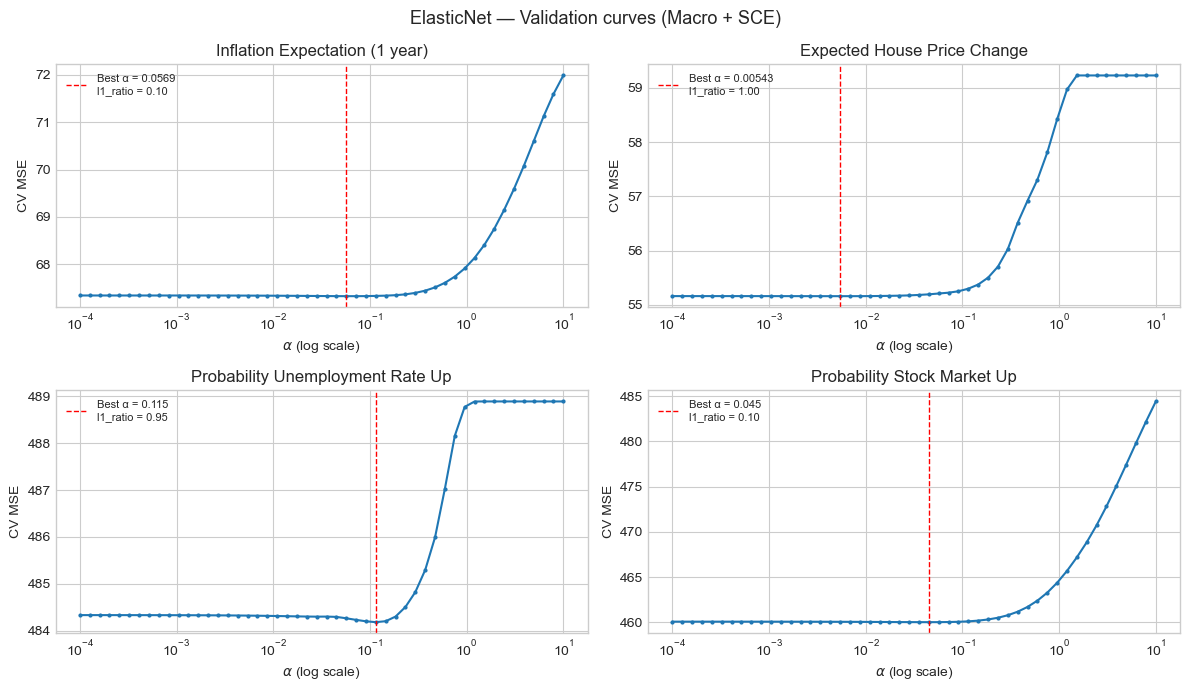

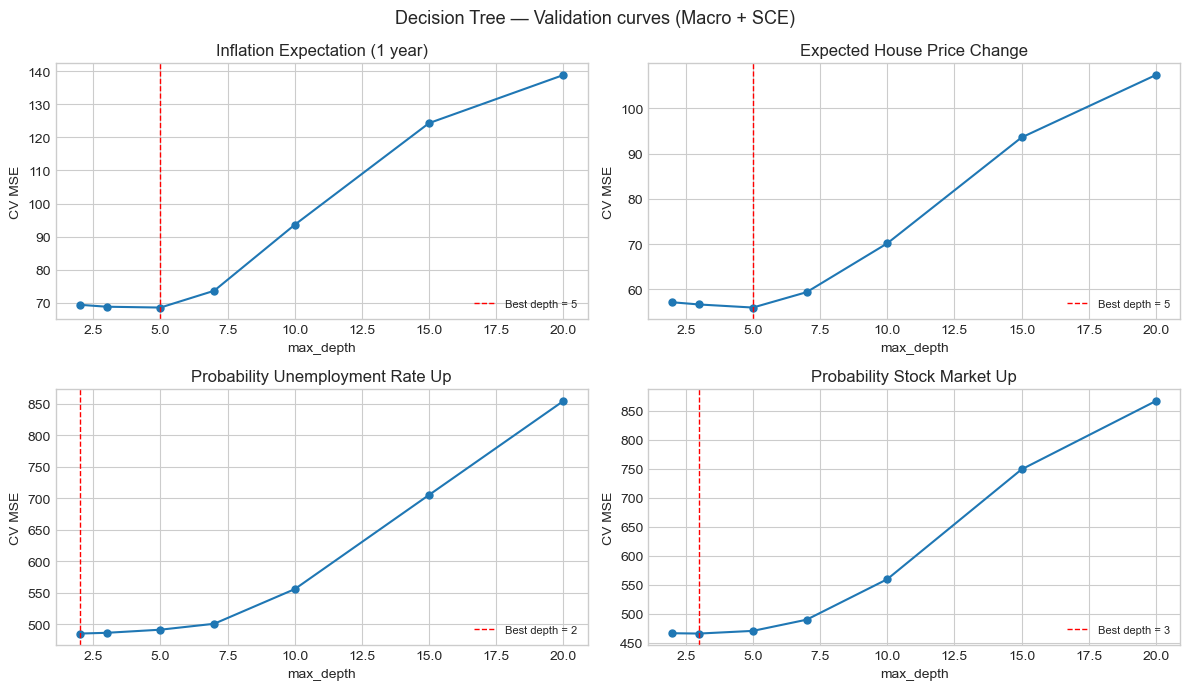

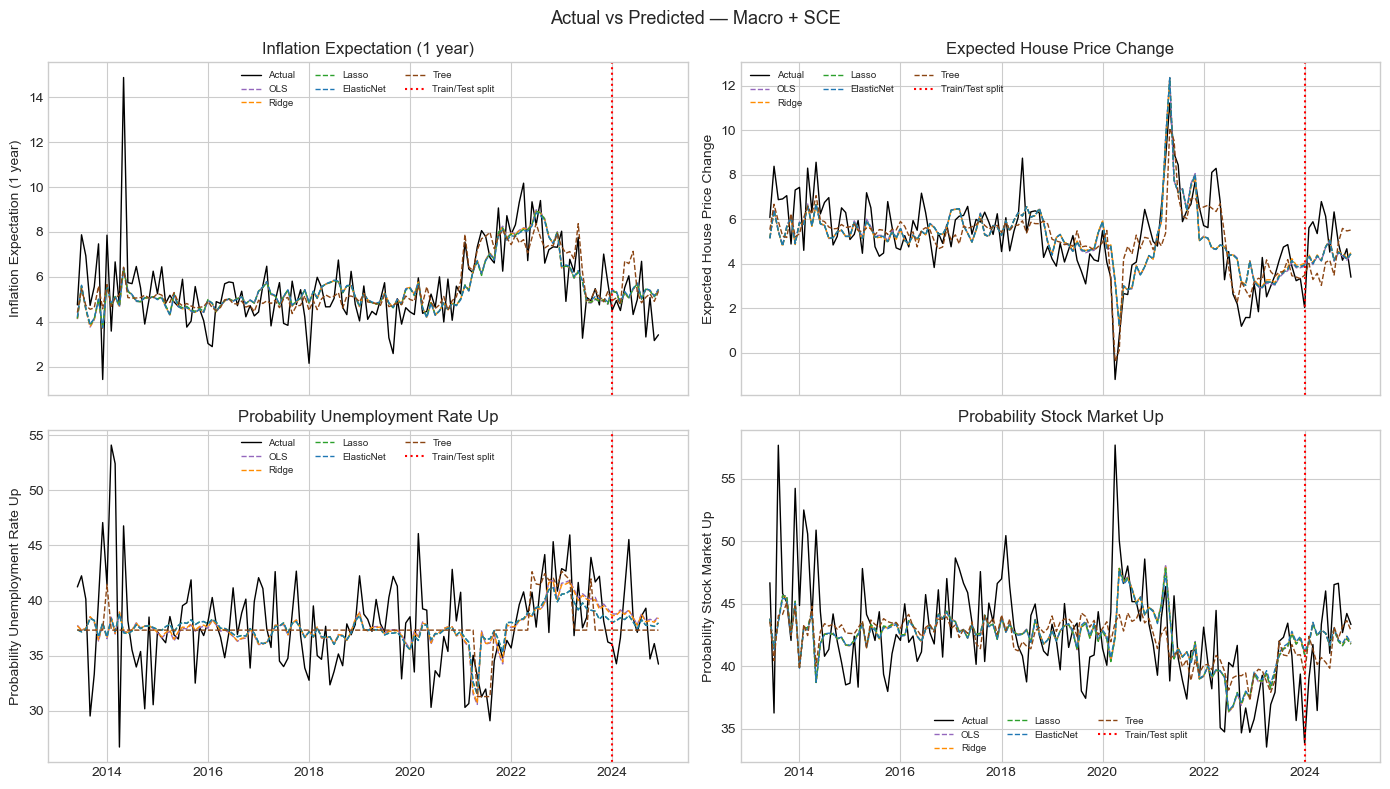

In [41]:
all_metrics = []

for fs_name, features in FEATURE_SETS.items():
    print(f"\n{'='*70}\nFeature set: {fs_name}\n{'='*70}")

    X_tr = X_train_full[features]
    X_te = X_test_full[features]

    # ── Ridge: multi-output (all four targets simultaneously) ─────────────
    print("Fitting Ridge (multi-output, 5-fold CV)…")
    pipe_ridge, ridge_alpha, ridge_alphas_ord, ridge_mse = fit_ridge_multioutput(
        X_tr, y_train_full, ridge_alphas, cv=5
    )
    print(f"  Best α = {ridge_alpha:.4g}")
    plot_ridge_validation_curve(ridge_alphas_ord, ridge_mse, ridge_alpha, fs_name)

    ridge_pred_tr = pipe_ridge.predict(X_tr)
    ridge_pred_te = pipe_ridge.predict(X_te)

    preds_tr = {t: {"Ridge": ridge_pred_tr[:, i]} for i, t in enumerate(TARGETS)}
    preds_te = {t: {"Ridge": ridge_pred_te[:, i]} for i, t in enumerate(TARGETS)}

    # ── Per-target models ─────────────────────────────────────────────────
    lasso_results = {}
    en_results    = {}
    tree_results  = {}

    for target in TARGETS:
        y_tr = y_train_full[target]
        y_te = y_test_full[target]

        # OLS
        pipe_ols = make_pipeline(StandardScaler(), LinearRegression())
        pipe_ols.fit(X_tr, y_tr)
        preds_tr[target]["OLS"] = pipe_ols.predict(X_tr)
        preds_te[target]["OLS"] = pipe_ols.predict(X_te)

        # Lasso
        print(f"Fitting Lasso for {target}…")
        pipe_lasso, lasso_alpha, lasso_alphas_ord, lasso_mse = fit_lasso_per_target(
            X_tr, y_tr, lasso_alphas, cv=5
        )
        print(f"  Best α = {lasso_alpha:.4g}")
        preds_tr[target]["Lasso"] = pipe_lasso.predict(X_tr)
        preds_te[target]["Lasso"] = pipe_lasso.predict(X_te)
        lasso_results[target] = (lasso_alpha, lasso_alphas_ord, lasso_mse)

        # ElasticNet
        print(f"Fitting ElasticNet for {target}…")
        pipe_en, en_alpha, en_l1, en_alphas_ord, en_mse = fit_elasticnet_per_target(
            X_tr, y_tr, l1_ratios, lasso_alphas, cv=5
        )
        print(f"  Best α = {en_alpha:.4g}  |  l1_ratio = {en_l1:.2f}")
        preds_tr[target]["ElasticNet"] = pipe_en.predict(X_tr)
        preds_te[target]["ElasticNet"] = pipe_en.predict(X_te)
        en_results[target] = (en_alpha, en_l1, en_alphas_ord, en_mse)

        # Decision Tree
        print(f"Fitting Decision Tree for {target}…")
        pipe_tree, best_depth, depths_ord, tree_mse = fit_tree_per_target(
            X_tr, y_tr, tree_depths, cv=5
        )
        print(f"  Best max_depth = {best_depth}")
        preds_tr[target]["Tree"] = pipe_tree.predict(X_tr)
        preds_te[target]["Tree"] = pipe_tree.predict(X_te)
        tree_results[target] = (best_depth, depths_ord, tree_mse)

        # Test-set metrics for all five models
        for model_name in ["OLS", "Ridge", "Lasso", "ElasticNet", "Tree"]:
            y_pred = preds_te[target][model_name]
            all_metrics.append({
                "target":      target,
                "feature_set": fs_name,
                "model":       model_name,
                "RMSE":        np.sqrt(mean_squared_error(y_te, y_pred)),
                "R2":          r2_score(y_te, y_pred),
            })

    # ── Plots: all collected after fitting ────────────────────────────────
    plot_lasso_validation_curves(lasso_results, fs_name)
    plot_elasticnet_validation_curves(en_results, fs_name)
    plot_tree_validation_curves(tree_results, fs_name)
    plot_ts_grid(
        dates_train, dates_test,
        y_train_full, y_test_full,
        preds_tr, preds_te, fs_name,
    )

In [42]:
results_df = pd.DataFrame(all_metrics)
results_df

,target,feature_set,model,RMSE,R2
0,infl_1y,Macro only,OLS,9.512177,-0.001715
1,infl_1y,Macro only,Ridge,9.512805,-0.001848
2,infl_1y,Macro only,Lasso,9.512484,-0.001780
3,infl_1y,Macro only,ElasticNet,9.515048,-0.002320
4,infl_1y,Macro only,Tree,9.502972,0.000222
5,house_price_change,Macro only,OLS,8.475130,-0.003497
6,house_price_change,Macro only,Ridge,8.471049,-0.002530
7,house_price_change,Macro only,Lasso,8.475097,-0.003489
8,house_price_change,Macro only,ElasticNet,8.474139,-0.003262
9,house_price_change,Macro only,Tree,8.460869,-0.000122


In [43]:
# For all targets, find max R2 and min RMSE, and which model/feature set achieves them
summary = []
for target in TARGETS:
    df_t = results_df[results_df["target"] == target]

    best_r2_row = df_t.loc[df_t["R2"].idxmax()]
    best_rmse_row = df_t.loc[df_t["RMSE"].idxmin()]

    summary.append({
        "target": target,
        "best_R2": best_r2_row["R2"],
        "best_R2_model": best_r2_row["model"],
        "best_R2_features": best_r2_row["feature_set"],
        "best_RMSE": best_rmse_row["RMSE"],
        "best_RMSE_model": best_rmse_row["model"],
        "best_RMSE_features": best_rmse_row["feature_set"],
    })
summary_df = pd.DataFrame(summary)
summary_df

,target,best_R2,best_R2_model,best_R2_features,best_RMSE,best_RMSE_model,best_RMSE_features
0,infl_1y,0.032708,OLS,Macro + SCE,9.347308,OLS,Macro + SCE
1,house_price_change,0.036859,Ridge,Macro + SCE,8.302970,Ridge,Macro + SCE
2,prob_unrate_up,0.026171,Ridge,Macro + SCE,22.831107,Ridge,Macro + SCE
3,prob_stocks_up,0.090493,OLS,Macro + SCE,22.065784,OLS,Macro + SCE


# WITHOUT ADDITIONAL MODELS (ELASTICNET AND DECISIONTREE)